<a href="https://colab.research.google.com/github/Grzegorz-GG/DissertationPW/blob/main/Experiment30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [6]:
output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [7]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [ ]:
# def load_data(directory: str):
#     data = []

#     all_files = np.array(
#         sorted(
#             glob(os.path.join(directory, "*.npz")),
#             key=lambda x: int(os.path.basename(x).replace(".npz", "")),
#         )
#     )

#     for file_name in all_files:
#         with np.load(file_name) as npz:
#             raw_arr = np.ma.MaskedArray(data=npz['data'], mask=npz['mask'])
#             img_tensor_raw = torch.as_tensor(raw_arr.data, dtype=torch.float)
#             img_tensor_mask = ~torch.as_tensor(raw_arr.mask) # Revert mask: 0 is invalid, 1 is valid
#             img_tensor_masked = torch.mul(img_tensor_raw, img_tensor_mask)
#         data.append(img_tensor_masked)

#     return data

In [8]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            # Create masked array
            raw_arr = np.ma.MaskedArray(
                data=npz['data'],
                mask=npz['mask']
            )

            # Raw tensor (KEEP values as-is)
            img_tensor = torch.as_tensor(raw_arr.data, dtype=torch.float32)

            # Mask: 1 = valid, 0 = invalid
            mask = ~torch.as_tensor(raw_arr.mask)

        # Store BOTH
        data.append((img_tensor, mask))

    return data

In [9]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [10]:
X_train_full_data = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [11]:
original_spectral_channels = X_train_full_data[0][0].shape[0]
print(f"Original spectral channels: {original_spectral_channels}")
reduced_spectral_channels = 3 # Number of channels after 1x1 convolution

Original spectral channels: 150


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train_full_data
original_indices = np.arange(len(X_train_full_data))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train_full_data, y_train, original_indices, test_size=0.2, random_state=93
)

# Then, split remaining 80% into train/val (20% val of original, means 25% of X_temp)
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.25, random_state=93
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")

Train patches: 1038
Validation patches: 347
Test patches: 347


In [13]:
def _pad_to_size_static(x, mask, size=(224, 224)):
    _, h, w = x.shape
    th, tw = size

    # ---- STEP 1: CROP if too large ----
    if h > th:
        start_h = (h - th) // 2
        x = x[:, start_h:start_h + th, :]
        mask = mask[:, start_h:start_h + th, :]
        h = th

    if w > tw:
        start_w = (w - tw) // 2
        x = x[:, :, start_w:start_w + tw]
        mask = mask[:, :, start_w:start_w + tw]
        w = tw

    # ---- STEP 2: PAD if too small ----
    pad_h = th - h
    pad_w = tw - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
    mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

    return x, mask

def calculate_global_stats(X_data, pad_function):
    print("Calculating global per-channel means and std deviations from training data...")

    # Initialize lists to store valid pixel values for each channel
    num_channels = X_data[0][0].shape[0]
    channel_data = [[] for _ in range(num_channels)]

    for x_item, mask_item in tqdm(X_data, desc="Processing X_data for global stats"):
        # Pad to consistent size first, as this affects the mask and values
        x_padded, mask_padded = pad_function(x_item, mask_item)

        # Extract valid pixels per channel
        for c in range(num_channels):
            valid_c_pixels = x_padded[c][mask_padded[c]].cpu().numpy()
            channel_data[c].extend(valid_c_pixels)

    # Calculate global mean and std for each channel
    global_means = torch.tensor([np.mean(c_data) for c_data in channel_data], dtype=torch.float32)
    global_stds = torch.tensor([np.std(c_data) for c_data in channel_data], dtype=torch.float32)

    print(f"Global Means (per channel): {global_means}")
    print(f"Global Std Devs (per channel): {global_stds}")
    return global_means, global_stds

# Call the new function to calculate global_means and global_stds
global_means, global_stds = calculate_global_stats(X_train_final, _pad_to_size_static)


Calculating global per-channel means and std deviations from training data...


Processing X_data for global stats: 100%|██████████| 1038/1038 [00:57<00:00, 18.13it/s]


Global Means (per channel): tensor([ 335.9208,  335.9069,  331.7341,  338.8154,  347.5788,  364.8742,
         374.7284,  375.6686,  377.9044,  380.5071,  385.3977,  393.0356,
         398.9632,  414.6352,  429.2801,  437.0627,  446.8707,  456.7486,
         466.4856,  467.3013,  475.4815,  490.8455,  513.5848,  538.7640,
         552.9874,  561.9896,  574.5370,  582.4282,  594.5684,  603.2874,
         615.0793,  623.9404,  630.4449,  633.6147,  633.7065,  634.5967,
         641.4842,  646.1486,  654.0912,  663.0143,  672.3674,  677.5461,
         681.8059,  684.6404,  691.3089,  698.3139,  701.8467,  701.3326,
         704.2673,  707.9794,  713.8121,  717.9084,  720.1819,  720.1807,
         724.6096,  729.8087,  735.5328,  749.8523,  756.5817,  753.4753,
         745.9611,  736.2238,  730.0534,  727.6396,  731.4945,  725.1307,
         721.3279,  725.2855,  735.6935,  767.1006,  809.9006,  859.7301,
         909.7721,  953.6044,  989.5249, 1022.1210, 1063.2218, 1101.7101,
        11

In [14]:
global_means.shape

torch.Size([150])

In [15]:
global_stds.shape

torch.Size([150])

In [16]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [17]:
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2


class RandomRot90:
    """Randomly rotate by 0/90/180/270 degrees — valid for fields with no natural orientation."""
    def __call__(self, x):
        k = torch.randint(0, 4, (1,)).item()
        return torch.rot90(x, k, dims=(-2, -1))


class RandomSpectralDrop:
    """Zero out random spectral channels to prevent over-reliance on specific bands."""
    def __init__(self, drop_prob=0.05):
        self.drop_prob = drop_prob

    def __call__(self, x):
        keep = torch.bernoulli(torch.ones(x.shape[0]) * (1 - self.drop_prob))
        return x * keep.view(-1, 1, 1)


class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels = None, augment=True, size=(224, 224), global_means=None, global_stds=None):
        """
        tensor_list: list of tuples -> [(x, mask), ...]
                     x: (C, H, W)
                     mask: (C, H, W) with 1=valid, 0=invalid
        """
        self.tensor_list = tensor_list
        self.labels = labels
        self.augment = augment
        self.size = size
        self.global_means = global_means
        self.global_stds = global_stds

        self.transform_aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            RandomRot90(),
            RandomSpectralDrop(drop_prob=0.05),
        ])

        #self.transform_basic = v2.Compose([])

    def __len__(self):
        return len(self.tensor_list)

    # ┅ Crop (if too large) + Pad (if too small)
    def pad_to_size(self, x, mask):
        _, h, w = x.shape
        th, tw = self.size

        # ---- STEP 1: CROP if too large ----
        if h > th:
            start_h = (h - th) // 2
            x = x[:, start_h:start_h + th, :]
            mask = mask[:, start_h:start_h + th, :]
            h = th

        if w > tw:
            start_w = (w - tw) // 2
            x = x[:, :, start_w:start_w + tw]
            mask = mask[:, :, start_w:start_w + tw]
            w = tw

        # ---- STEP 2: PAD if too small ----
        pad_h = th - h
        pad_w = tw - w

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), value=0)
        mask = F.pad(mask, (pad_left, pad_right, pad_top, pad_bottom), value=0)

        return x, mask

    def normalize_with_mask(self, x, mask):
        # mask: 1 = valid, 0 = invalid
        if self.global_means is not None and self.global_stds is not None:
            # Use global per-channel statistics for normalization
            # Reshape global_means and global_stds to (C, 1, 1) for broadcasting
            x_norm = (x - self.global_means.to(x.device).view(-1, 1, 1)) / \
                     (self.global_stds.to(x.device).view(-1, 1, 1) + 1e-6)

        # ---- IMPORTANT: keep invalid pixels neutral ----
        x_norm = x_norm * mask

        return x_norm

    def __getitem__(self, idx):
        x, mask = self.tensor_list[idx]

        # 1. FIX SIZE FIRST
        x, mask = self.pad_to_size(x, mask)

        # 2. NORMALIZE USING MASK
        x = self.normalize_with_mask(x, mask)

        # 4. AUGMENTATION (only if labels are present, typically for training/validation)
        if self.augment and self.labels is not None:
            x = self.transform_aug(x)
            x = x * mask  # re-zero invalid pixels corrupted by GaussianNoise

        if self.labels is not None:
            y = torch.tensor(self.labels[idx], dtype=torch.float32)
            return x, y
        else:
            # For submission or inference without labels, return only the features
            return x


In [18]:
def check_normalized_stats(dataset: NPZDataset, device: torch.device):
    """
    Checks the per-channel mean and standard deviation of data AFTER normalization.
    It re-applies padding and normalization from the dataset's methods to raw data
    and then calculates statistics only on valid (non-masked) normalized pixels.
    """
    print("\nChecking per-channel means and std deviations for normalized data...")

    num_channels = dataset.tensor_list[0][0].shape[0]
    channel_data_normalized = [[] for _ in range(num_channels)]

    for idx in tqdm(range(len(dataset)), desc="Processing dataset for normalized stats"): # Iterate through the original data for accurate stats
        x_raw, mask_raw = dataset.tensor_list[idx]

        # Apply padding using the dataset's method
        x_padded, mask_padded = dataset.pad_to_size(x_raw, mask_raw)

        # Apply normalization using the dataset's method (which uses global_means/stds)
        x_normalized = dataset.normalize_with_mask(x_padded, mask_padded)

        # Extract valid pixels per channel from the normalized data
        for c in range(num_channels):
            # Ensure mask_padded is also on CPU if x_normalized is on CPU for indexing
            valid_c_pixels = x_normalized[c][mask_padded[c]].cpu().numpy()
            channel_data_normalized[c].extend(valid_c_pixels)

    # Calculate mean and std for each channel from the normalized valid pixels
    means_normalized = torch.tensor([np.mean(c_data) for c_data in channel_data_normalized if len(c_data) > 0], dtype=torch.float32)
    stds_normalized = torch.tensor([np.std(c_data) for c_data in channel_data_normalized if len(c_data) > 0], dtype=torch.float32)

    print(f"Normalized Means (per channel): {means_normalized}")
    print(f"Normalized Std Devs (per channel): {stds_normalized}")
    return means_normalized, stds_normalized

In [19]:
# -----------------------
# Create Dataset and DataLoader with global stats
# -----------------------

train_dataset = NPZDataset(X_train_final, y_train_final_scaled, augment=True, global_means=global_means, global_stds=global_stds)
val_dataset   = NPZDataset(X_val, y_val_scaled, augment=False, global_means=global_means, global_stds=global_stds)
test_dataset  = NPZDataset(X_test, y_test_scaled, augment=False, global_means=global_means, global_stds=global_stds)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


In [20]:
# Verify normalization for the training dataset
normalized_means_train, normalized_stds_train = check_normalized_stats(train_dataset, device)


Checking per-channel means and std deviations for normalized data...


Processing dataset for normalized stats: 100%|██████████| 1038/1038 [00:56<00:00, 18.48it/s]


Normalized Means (per channel): tensor([-1.6917e-07, -2.1575e-06, -1.6974e-06,  2.2670e-06,  1.0800e-06,
         5.7066e-07,  4.0319e-07, -4.4846e-08,  1.5490e-06,  4.5173e-07,
         1.2925e-06,  9.3070e-07,  8.1305e-07,  2.1447e-06, -8.2540e-07,
        -1.8790e-07, -1.6766e-06,  5.3532e-07, -4.3598e-07, -6.7866e-07,
        -2.6652e-07, -5.8754e-07,  6.0883e-07, -2.4098e-07, -4.4392e-07,
         1.6284e-06,  1.5577e-06,  1.1351e-06, -1.5242e-06,  1.7853e-07,
         2.0067e-07,  4.3541e-07,  1.3372e-06,  6.1394e-07,  5.0949e-07,
         1.0806e-06, -8.7309e-07, -1.1166e-06,  3.9879e-07,  1.9423e-06,
         1.2858e-07,  1.7536e-06, -3.8318e-08,  1.4447e-06,  9.5370e-07,
         2.2599e-06,  1.1839e-06, -6.8121e-07,  4.6039e-07, -1.6355e-06,
         1.3658e-06,  4.2462e-07, -1.7618e-06,  8.8586e-07, -1.2091e-07,
        -7.4309e-07, -6.4346e-07, -6.0287e-07,  3.0470e-07, -1.0786e-06,
         8.2867e-07,  3.7311e-07, -8.2072e-07, -1.2307e-06,  2.6028e-07,
         1.2943e-07

In [21]:
import torch
import torch.nn as nn
import timm

class HyperspectralRegressor(nn.Module):
    def __init__(
        self,
        original_in_channels: int = 150,
        reduced_in_channels: int = 10,
        n_outputs: int = 4,
        backbone_name: str = "efficientnet_b0",
        pretrained: bool = False,
        dropout: float = 0.3,
        regressor: nn.Module = None,
    ):
        """
        original_in_channels: Number of input spectral bands (masked pixels are zero).
        reduced_in_channels: Number of channels after 1x1 convolution.
        n_outputs: Number of regression outputs.
        backbone_name: Name of the model in timm.
        pretrained: Whether to load ImageNet weights (safe only if reduced_in_channels==3).
        """
        super().__init__()

        # 1x1 spectral reducer: Conv -> BN -> ReLU
        # self.spectral_reducer = nn.Sequential(
        #     nn.Conv2d(original_in_channels, reduced_in_channels, kernel_size=1, bias=True),
        #     # nn.BatchNorm2d(reduced_in_channels),
        #     # nn.ReLU(inplace=True),
        # )

        self.spectral_reducer = nn.Sequential(
            nn.Conv2d(original_in_channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, reduced_in_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(reduced_in_channels),
        )

        effective_pretrained = pretrained
        if pretrained and reduced_in_channels != 3:
            effective_pretrained = False

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=effective_pretrained,
            in_chans=reduced_in_channels,
            num_classes=0,
        )

        feat_dim = getattr(self.backbone, "num_features", None)
        if feat_dim is None:
            if hasattr(self.backbone, "fc") and hasattr(self.backbone.fc, "in_features"):
                feat_dim = self.backbone.fc.in_features
            else:
                raise RuntimeError("Backbone features cannot be determined")

        # Use provided regressor or default to the original one
        if regressor is None:
            # self.regressor = nn.Sequential(
            #     nn.Linear(feat_dim, 512),
            #     nn.ReLU(inplace=True),
            #     # nn.Dropout(dropout),
            #     nn.Linear(512, n_outputs),
            # )
            self.regressor = nn.Sequential(
                nn.Linear(feat_dim, 256),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(256, 64),
                nn.GELU(),
                nn.Dropout(dropout / 2),
                nn.Linear(64, n_outputs),
            )
        else:
            self.regressor = regressor

        # nn.init.kaiming_normal_(self.spectral_reducer[0].weight, nonlinearity="relu")
        # if self.spectral_reducer[0].bias is not None:
        #     nn.init.zeros_(self.spectral_reducer[0].bias)

    def forward(self, x):
        """
        x: (B, original_in_channels, H, W)  -- masked pixels = 0
        returns: (B, n_outputs)
        """
        x = self.spectral_reducer(x)      # (B, reduced_in_channels, H, W)
        features = self.backbone(x)       # (B, feat_dim)
        out = self.regressor(features)    # (B, n_outputs)
        return out

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


## **Overfitting on one batch**

In [22]:
def overfit_single_batch(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    x_single: torch.Tensor,
    y_single: torch.Tensor,
    epochs: int = 500,
    device: torch.device = torch.device("cpu")
):
    """
    Performs overfitting of a model on a single batch of data.

    Args:
        model (nn.Module): The model to overfit.
        criterion (nn.Module): The loss function.
        optimizer (optim.Optimizer): The optimizer.
        x_single (torch.Tensor): The input features for the single batch.
        y_single (torch.Tensor): The target labels for the single batch.
        epochs (int): The number of epochs to train for.
        device (torch.device): The device (CPU/GPU) to run the training on.
    """
    print(f"\n--- Starting Overfitting on Single Batch for {epochs} epochs ---")

    x_single, y_single = x_single.to(device), y_single.to(device)

    for epoch_overfit in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs_overfit = model(x_single)
        loss_overfit = criterion(outputs_overfit, y_single)

        loss_overfit.backward()
        optimizer.step()

        if (epoch_overfit + 1) % 10 == 0 or epoch_overfit == 0:
            print(f"Overfit Epoch {epoch_overfit+1}/{epochs} - Loss: {loss_overfit.item():.6f}")

    print("--- Overfitting complete ---")

In [23]:
train_data_single_batch = next(iter(train_loader))

In [24]:
train_data_single_batch[0].shape

torch.Size([64, 150, 224, 224])

In [25]:
train_data_single_batch[1].shape

torch.Size([64, 4])

In [27]:
import torch
import torch.nn as nn
import timm

# Re-initialize a fresh model for overfitting
model_overfit = HyperspectralRegressor(
    reduced_in_channels = 3,   # reduced channels
    n_outputs = 4,      # P, K, Mg, pH
    backbone_name = "convnext_tiny_in22k",
    pretrained = True  # Use pre-trained weights
)
model_overfit = model_overfit.to(device)

# Define optimizer and criterion for overfitting
#optimizer_overfit = optim.AdamW(model_overfit.parameters(), lr=8e-5, weight_decay=1e-4)

optimizer_overfit = optim.AdamW([
    {"params": model_overfit.spectral_reducer.parameters(), "lr": 1e-4},
    {"params": model_overfit.backbone.parameters(), "lr": 1e-5},
    {"params": model_overfit.regressor.parameters(), "lr": 1e-4},
], weight_decay=1e-3)

#criterion_overfit = nn.SmoothL1Loss(beta=1.0)
criterion_overfit = nn.MSELoss()

# Extract the single batch
x_single, y_single = train_data_single_batch

# Move x_single and y_single to the device for consistent usage
x_single = x_single.to(device)
y_single = y_single.to(device)

# Call the overfit_single_batch function
overfit_single_batch(
    model=model_overfit,
    criterion=criterion_overfit,
    optimizer=optimizer_overfit,
    x_single=x_single,
    y_single=y_single,
    epochs=200,
    device=device
)


--- Starting Overfitting on Single Batch for 200 epochs ---
Overfit Epoch 1/200 - Loss: 0.907098
Overfit Epoch 10/200 - Loss: 0.830005
Overfit Epoch 20/200 - Loss: 0.733760
Overfit Epoch 30/200 - Loss: 0.614684
Overfit Epoch 40/200 - Loss: 0.459078
Overfit Epoch 50/200 - Loss: 0.343995
Overfit Epoch 60/200 - Loss: 0.251750
Overfit Epoch 70/200 - Loss: 0.205091
Overfit Epoch 80/200 - Loss: 0.143946
Overfit Epoch 90/200 - Loss: 0.119449
Overfit Epoch 100/200 - Loss: 0.083941
Overfit Epoch 110/200 - Loss: 0.087298
Overfit Epoch 120/200 - Loss: 0.058063
Overfit Epoch 130/200 - Loss: 0.043019
Overfit Epoch 140/200 - Loss: 0.050185
Overfit Epoch 150/200 - Loss: 0.052411
Overfit Epoch 160/200 - Loss: 0.039793
Overfit Epoch 170/200 - Loss: 0.034567
Overfit Epoch 180/200 - Loss: 0.038370
Overfit Epoch 190/200 - Loss: 0.039337
Overfit Epoch 200/200 - Loss: 0.033880
--- Overfitting complete ---


In [28]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval() # Set model to evaluation mode

with torch.no_grad():
    outputs_single_batch = model_overfit(x_single)

print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


--- Model Overfit Predictions vs. True Values ---
Predictions:
[[ 2.20681697e-01  2.71906853e-01 -7.35211670e-01  7.12235093e-01]
 [ 1.60296842e-01 -4.98817265e-01 -5.59995770e-02 -1.09749341e+00]
 [-8.98582160e-01 -3.37656438e-01 -3.31620604e-01  9.28159207e-02]
 [ 1.32514656e+00  1.35954869e+00 -9.82454419e-03 -3.11956227e-01]
 [-6.86729401e-02 -1.31874466e+00 -8.79379630e-01 -3.40985656e-01]
 [-4.43207800e-01 -5.48059225e-01 -7.25876510e-01  1.75232068e-02]
 [-1.49878156e+00 -6.59824371e-01  4.39225292e+00  8.54644537e-01]
 [-6.96714520e-02  8.80050778e-01  4.58579183e-01  8.45498800e-01]
 [ 3.46068740e-01 -1.00012171e+00 -2.26863670e+00 -6.20038867e-01]
 [-5.56679785e-01  5.48624516e-01  4.42142457e-01  9.85068232e-02]
 [ 8.03724408e-01  1.13262200e+00 -1.51348472e-01 -2.87473381e-01]
 [-9.41672623e-01 -5.65979540e-01 -7.81648397e-01 -1.12842679e+00]
 [ 6.40736282e-01 -5.48369706e-01 -3.09356511e-01  3.00118439e-02]
 [ 5.26367486e-01  1.53458610e-01  9.74650264e-01 -3.22188318e-01

In [29]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[ 76.68086   244.62651   129.54214     6.9668713]
 [ 74.95227   198.26602   156.33635     6.503504 ]
 [ 44.640594  207.96014   145.4634      6.8082733]
 [108.297485  310.0502    158.1579      6.7046347]
 [ 68.397736  148.94585   123.854866    6.6972017]
 [ 57.67623   195.30402   129.9104      6.7889953]
 [ 27.459173  188.58113   331.81525     7.003334 ]
 [ 68.369156  281.20752   176.63594     7.0009923]
 [ 80.27022   168.11162    69.05013     6.6257524]
 [ 54.42796   261.2716    175.98753     6.8097305]
 [ 93.371155  296.40015   152.57494     6.710903 ]
 [ 43.40708   194.22607   127.710266    6.4955835]
 [ 88.70542   195.28534   146.34167     6.792193 ]
 [ 85.43148   237.50163   196.9944      6.702015 ]
 [ 52.131165  218.07414   153.16992     7.1679487]
 [ 65.55538   188.71939   195.79811     6.9011955]
 [ 53.45267   202.721     129.84883     6.7675514]
 [ 46.649063  182.162

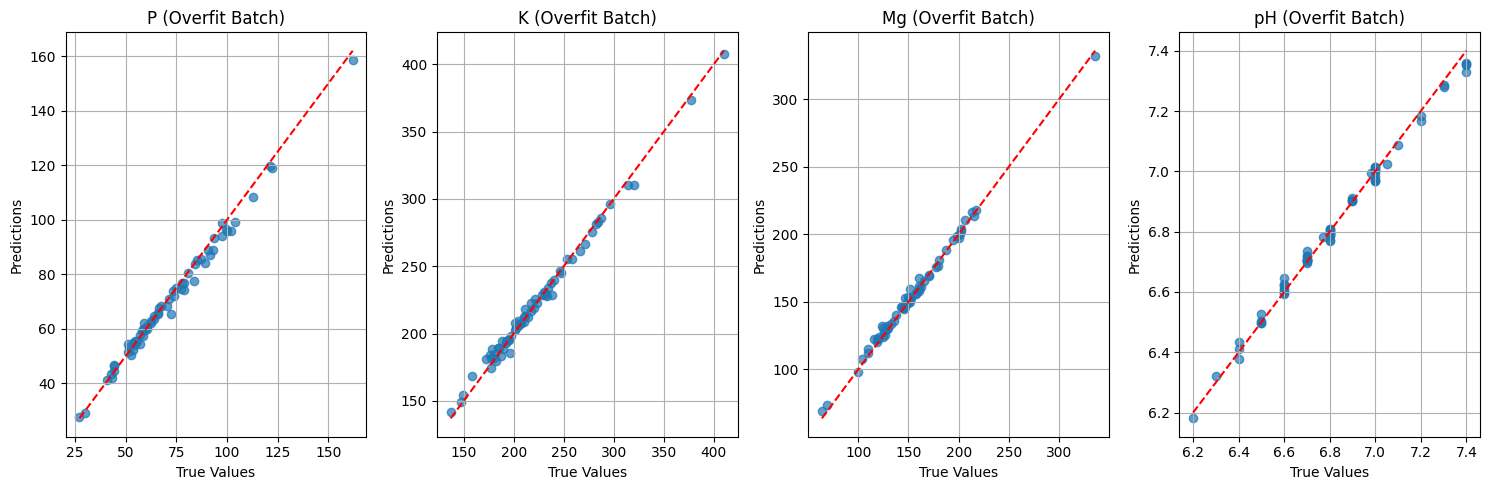

In [30]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


# **Training loop**

In [32]:
import os
import torch
from tqdm import tqdm

def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,            # ReduceLROnPlateau expected
    criterion,
    device,
    epochs=120,
    warmup_epochs=5,
    patience=20,
    save_path="best_hyperspectral_model.pth",
    use_amp=False, # Re-introduced use_amp parameter
    max_grad_norm=1.0,
    wandb_run=None
):
    # initial LRs per param_group (order must match how optimizer was created)
    initial_lrs = [pg['lr'] for pg in optimizer.param_groups]

    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        # ---------- TRAIN ----------
        model.train()
        train_running_loss = 0.0
        train_samples = 0

        # linear warmup
        if epoch < warmup_epochs:
            warmup_factor = (epoch + 1) / float(warmup_epochs)
            for i, pg in enumerate(optimizer.param_groups):
                pg['lr'] = initial_lrs[i] * warmup_factor

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for xb, yb in loop:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()

            preds = model(xb)
            loss = criterion(preds, yb)

            loss.backward()

            # Calculate gradient norm before clipping
            #total_norm = torch.sqrt(
            #    sum(p.grad.detach().norm(2)**2 for p in model.parameters() if p.grad is not None)
            #)

            # for name, p in model.named_parameters():
            #   if p.grad is not None:
            #       print(name, p.grad.abs().mean().item())
            #       break

            # Clip gradient
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            bsz = xb.size(0)
            train_running_loss += loss.item() * bsz
            train_samples += bsz

            loop.set_postfix(
                train_loss=loss.item(),
                # grad_norm=total_norm.item(), # Log gradient norm
                lr_spectral_reducer=optimizer.param_groups[0]['lr'],
                lr_backbone=optimizer.param_groups[1]['lr'],
                lr_head=optimizer.param_groups[2]['lr']
            )

        train_loss = train_running_loss / max(1, train_samples)

        # ---------- VALIDATION ----------
        model.eval()
        val_running_loss = 0.0
        val_samples = 0
        # optional threshold for logging outlier batches (set after first epoch if desired)
        outlier_threshold = None

        with torch.no_grad():
            for i, (xv, yv) in enumerate(val_loader):
                xv = xv.to(device, non_blocking=True)
                yv = yv.to(device, non_blocking=True)

                vpreds = model(xv)
                vloss = criterion(vpreds, yv)

                bsz = xv.size(0)
                val_running_loss += vloss.item() * bsz
                val_samples += bsz

                # detect very large batch losses for debugging
                if outlier_threshold is not None and vloss.item() > outlier_threshold:
                    print(f"[DEBUG] Large val batch loss epoch {epoch+1} batch {i}: {vloss.item():.4f}")
                    # optionally save xv, yv, vpreds.cpu() for inspection

        val_loss = val_running_loss / max(1, val_samples)

        # ---------- SCHEDULER ----------
        # Skip scheduler during warmup to prevent premature LR reduction
        if epoch >= warmup_epochs:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # ---------- LOGGING ----------
        current_lrs = [pg['lr'] for pg in optimizer.param_groups]
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - spectral reducer LR: {current_lrs[0]:.6f} - backbone LR: {current_lrs[1]:.6f} - head LR: {current_lrs[2]:.6f}")

        if wandb_run is not None:
            wandb_run.log({
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch": epoch + 1,
                "lr_spectral_reducer": current_lrs[0],
                "lr_backbone": current_lrs[1],
                "lr_head": current_lrs[2]
            })

        # ---------- EARLY STOPPING & CHECKPOINT ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            # save full checkpoint
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if hasattr(scheduler, "state_dict") else None,
                "val_loss": val_loss,
            }, save_path)
            print(f"Saved best model (val_loss={val_loss:.4f})")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    # load best model if exists
    if os.path.exists(save_path):
        ckpt = torch.load(save_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
    return model

In [33]:
# ----- Model -----
model = HyperspectralRegressor(
    reduced_in_channels = 3,   # reduced channels
    n_outputs = 4,      # P, K, Mg, pH
    backbone_name = "convnext_tiny_in22k",
    pretrained = True
)

model = model.to(device);

# ----- Optimizer -----
optimizer = optim.AdamW([
    {"params": model.spectral_reducer.parameters(), "lr": 1e-4},
    {"params": model.backbone.parameters(), "lr": 1e-5},
    {"params": model.regressor.parameters(), "lr": 1e-4},
], weight_decay=1e-3)

# ----- Loss -----
criterion = nn.MSELoss()
#criterion = nn.SmoothL1Loss(beta=1.0)

# ----- Scheduler -----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=10,
    min_lr=1e-6
)

# ----- Hyperparameters -----
epochs = 90
patience = 12  # Increased early stopping patience
warmup_epochs = 10 # Number of epochs for warm-up

# ----- Initialize wandb -----
# Initializing Weights & Biases for experiment tracking.
wandb.init(
    project="30 - convnext_tiny_in22k (pretrained=true)",
    config={
        "learning_rate_backbone": 1e-5, # Updated in config
        "learning_rate_head": 1e-4, # Updated in config
        "learning_rate_reduced": 1e-4, # Updated in config
        "weight_decay": 1e-3,
        "epochs": epochs,
        "batch_size": 64,
        "optimizer": "AdamW",
        "criterion": "MSELoss",
        "backbone": "convnext_tiny_in22k",
        "1x1_conv_filters": 3,
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 10,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs,
        "early_stopping_patience": patience,
        "use_amp": "False",
        # "gaussian_noise_enabled": "False",
        "augmentation_enabled": "True"
    }
)
# Log a note to wandb about this run's configuration
wandb.run.log({"note": "This run uses: (1) convnext_tiny_in22k backbone (pretrained=true) - augmentation enabled, (2) 1x1 conv used, (3) MSELoss, (4)padding instead of resize (!), (5) batch size 64, (6) Automatic Mixed Precision disabled, (7) Global normalization (!)"})

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name convnext_tiny_in22k to current convnext_tiny.fb_in22k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ggasowski977 (ggasowski977-politechnika-warszawska) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [34]:
train_with_early_stopping(
    model = model,
    train_loader = train_loader,
    val_loader = val_loader,
    optimizer = optimizer,
    scheduler = scheduler,            # ReduceLROnPlateau expected
    criterion = criterion,
    device = device,
    epochs  = epochs,
    warmup_epochs = warmup_epochs,
    patience = patience,
    save_path="best_hyperspectral_model.pth",
    max_grad_norm=1.0,
    wandb_run=wandb.run
)

# ----- Finish wandb -----
wandb.finish()

Epoch 1/90 - Train Loss: 1.0038 - Val Loss: 1.2011 - spectral reducer LR: 0.000010 - backbone LR: 0.000001 - head LR: 0.000010
Saved best model (val_loss=1.2011)


Epoch 2/90 - Train Loss: 1.0003 - Val Loss: 1.1949 - spectral reducer LR: 0.000020 - backbone LR: 0.000002 - head LR: 0.000020
Saved best model (val_loss=1.1949)


Epoch 3/90 - Train Loss: 0.9947 - Val Loss: 1.1860 - spectral reducer LR: 0.000030 - backbone LR: 0.000003 - head LR: 0.000030
Saved best model (val_loss=1.1860)


Epoch 4/90 - Train Loss: 0.9840 - Val Loss: 1.1697 - spectral reducer LR: 0.000040 - backbone LR: 0.000004 - head LR: 0.000040
Saved best model (val_loss=1.1697)


Epoch 5/90 - Train Loss: 0.9694 - Val Loss: 1.1569 - spectral reducer LR: 0.000050 - backbone LR: 0.000005 - head LR: 0.000050
Saved best model (val_loss=1.1569)


...

Epoch 45/90 - Train Loss: 0.6832 - Val Loss: 1.0529 - spectral reducer LR: 0.000100 - backbone LR: 0.000010 - head LR: 0.000100


Epoch 46/90 - Train Loss: 0.6749 - Val Loss: 1.0429 - spectral reducer LR: 0.000100 - backbone LR: 0.000010 - head LR: 0.000100


Epoch 47/90 - Train Loss: 0.6649 - Val Loss: 1.0379 - spectral reducer LR: 0.000030 - backbone LR: 0.000003 - head LR: 0.000030


Epoch 48/90 - Train Loss: 0.6596 - Val Loss: 1.0477 - spectral reducer LR: 0.000030 - backbone LR: 0.000003 - head LR: 0.000030
Early stopping at epoch 48 (no improvement for 12 epochs)


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr_backbone,▁▂▃▃▄▆▆▇███████████████████████████████▃
lr_head,▁▂▃▃▄▆▆▇███████████████████████████████▃
lr_spectral_reducer,▁▂▃▃▄▆▆▇███████████████████████████████▃
train_loss,████▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁
val_loss,██▇▇▆▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▁▁▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▂▁▂
epoch,48
lr_backbone,0.0
lr_head,3e-05
lr_spectral_reducer,3e-05
note,This run uses: (1) c...


In [35]:
# ----- Load best model -----
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## **Evaluate results in comparision to the Baseline Regressor.**

In [36]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [37]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    """Evaluates the deep learning model on the local test dataset."""
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = [] # To collect the true scaled labels from the DataLoader

    with torch.no_grad():
        for X_batch_test, y_batch_true_scaled in test_loader:
            X_batch_test = X_batch_test.to(device)
            preds_batch = model(X_batch_test)
            test_predictions_scaled.append(preds_batch.cpu().numpy())
            y_true_scaled.append(y_batch_true_scaled.cpu().numpy())

    y_test_scaled_pred = np.vstack(test_predictions_scaled)
    y_test_scaled_true = np.vstack(y_true_scaled)

    # Inverse transform predictions and true values
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)
    y_test_true_from_loader = scaler_y.inverse_transform(y_test_scaled_true)

    model_mse_targets = np.mean((y_test_true_from_loader - y_test_pred)**2, axis=0)
    return y_test_pred, y_test_true_from_loader, model_mse_targets

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    """Evaluates the baseline regressor on the test dataset."""
    baseline_preds_test = baseline_regressor.predict(X_test_filtered)
    baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)
    return baseline_preds_test, baseline_mse_targets

def calculate_and_print_results(model_mse_targets, baseline_mse_targets, y_test_true, y_test_pred, baseline_preds_test):
    """Calculates and prints the challenge score and per-target comparison, and plots results."""
    challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

    target_names = ["P", "K", "Mg", "pH"]
    print("Per-target comparison (on local test set from training data):")
    for i, name in enumerate(target_names):
        print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

    print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

    # Plotting
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(target_names):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_test_true[:, i], y_test_pred[:, i], alpha=0.7, label='DL Model Predictions')
        plt.scatter(y_test_true[:, i], baseline_preds_test[:, i], alpha=0.7, label='Baseline Predictions', marker='x')
        min_val = min(y_test_true[:, i].min(), y_test_pred[:, i].min(), baseline_preds_test[:, i].min())
        max_val = max(y_test_true[:, i].max(), y_test_pred[:, i].max(), baseline_preds_test[:, i].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
        plt.title(f'{metric} Predictions')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

In [38]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][1].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)

In [39]:
# We need the original unscaled, non-PCA data for the baseline regressor
X_test_nonpca = [X_train_full_data[i] for i in test_indices]

# We need to apply SpectralCurveFiltering to the original X_test_nonpca for the baseline regressor
filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_test_nonpca]) # Accessing the image tensor from tuple

# Train a new baseline regressor on the combined training and validation splits
# Combine train and validation indices
combined_train_val_indices = train_indices.tolist() + val_indices.tolist() # Convert to list for concatenation

# Get the original unscaled, non-PCA data for the baseline training
X_combined_train_val_nonpca = [X_train_full_data[i] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices] # Use unscaled y_train for baseline training

X_combined_train_val_filtered = np.array([filtering(cube[0].cpu().numpy()) for cube in X_combined_train_val_nonpca]) # Accessing the image tensor from tuple

In [40]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [41]:
# Load the best model weights
checkpoint = torch.load("best_hyperspectral_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Iterate through the local test loader to get predictions
test_predictions_scaled = []

# # Create a DataLoader for the local test dataset
# local_test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for X_batch_test, _ in test_loader:
        X_batch_test = X_batch_test.to(next(model.parameters()).device)
        preds_batch = model(X_batch_test)
        test_predictions_scaled.append(preds_batch.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled) # predicted in scaled units

# Convert to numpy and inverse scale to original units
y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

In [42]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 914.7599, Baseline MSE = 956.1005, Normalized = 0.9568
K: Model MSE = 2625.4749, Baseline MSE = 3448.3214, Normalized = 0.7614
Mg: Model MSE = 1259.4757, Baseline MSE = 1448.3911, Normalized = 0.8696
pH: Model MSE = 0.0604, Baseline MSE = 0.0677, Normalized = 0.8922

Challenge normalized score (lower is better, on local test set): 0.8700


Per-target comparison (on local test set from training data):
P: Model MSE = 914.7599, Baseline MSE = 956.1005, Normalized = 0.9568
K: Model MSE = 2625.4749, Baseline MSE = 3448.3214, Normalized = 0.7614
Mg: Model MSE = 1259.4757, Baseline MSE = 1448.3911, Normalized = 0.8696
pH: Model MSE = 0.0604, Baseline MSE = 0.0677, Normalized = 0.8922

Challenge normalized score (lower is better, on local test set): 0.8700


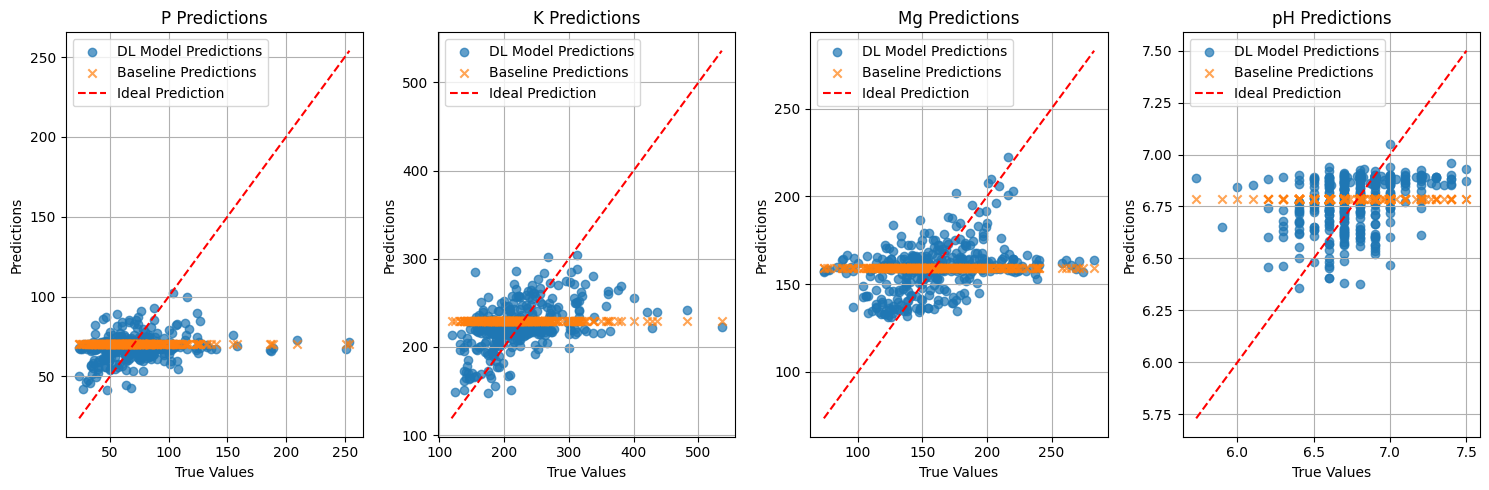

In [43]:
# Load the best model weights for the deep learning model
#model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

In [44]:
def display_predictions_table(model, test_loader, scaler_y, device):
    """Displays the model's predictions against ground truth values in a tabular form (unscaled)."""
    model.eval()  # Set the model to evaluation mode
    all_predictions_scaled = []
    all_true_values_scaled = []

    with torch.no_grad():
        for X_batch, y_batch_true_scaled in test_loader:
            X_batch = X_batch.to(device)
            preds_batch = model(X_batch)
            all_predictions_scaled.append(preds_batch.cpu().numpy())
            all_true_values_scaled.append(y_batch_true_scaled.cpu().numpy())

    # Concatenate all batches
    y_predictions_scaled = np.vstack(all_predictions_scaled)
    y_true_scaled = np.vstack(all_true_values_scaled)

    # Inverse transform to get original values
    y_predictions_unscaled = scaler_y.inverse_transform(y_predictions_scaled)
    y_true_unscaled = scaler_y.inverse_transform(y_true_scaled)

    # Create a DataFrame for display
    target_names = ["P", "K", "Mg", "pH"]

    # To ensure consistent number of samples, we'll just take a few examples from the test set
    num_samples_to_display = min(10, len(y_predictions_unscaled))

    # Correctly build the dictionary for DataFrame
    data_for_df = {}
    for i, name in enumerate(target_names):
        data_for_df[f'True {name}'] = y_true_unscaled[:num_samples_to_display, i]
        data_for_df[f'Pred {name}'] = y_predictions_unscaled[:num_samples_to_display, i]

    df_display = pd.DataFrame(data_for_df)

    print(f"\nSample of {num_samples_to_display} Predictions vs. True Values (Unscaled):")
    display(df_display)

# Example usage of the function:
display_predictions_table(model, test_loader, scaler_y, device)



Sample of 10 Predictions vs. True Values (Unscaled):


,True P,Pred P,True K,Pred K,True Mg,Pred Mg,True pH,Pred pH
0,64.599998,68.547874,243.0,254.269653,184.000000,140.855042,6.50,6.721293
1,36.099998,67.034058,193.0,215.932358,77.200005,158.078796,5.73,6.886310
2,56.400002,55.683620,213.0,200.055008,154.000000,162.369034,6.70,6.613837
3,46.500000,87.015198,146.0,227.861084,116.000000,134.326981,6.90,6.919250
4,57.599998,70.532181,234.0,259.235992,167.000000,178.872299,6.40,6.359308
5,68.400002,69.798462,230.0,219.863220,220.000000,164.188614,6.80,6.898158
6,35.500000,71.217094,132.0,203.703735,120.000000,132.765213,6.80,6.861276
7,96.199997,63.501835,226.0,235.769348,140.000000,161.078888,6.80,6.910951
8,45.400002,55.568424,209.0,242.520355,143.000000,165.831955,6.80,6.778260
9,123.000000,67.860008,363.0,217.607254,195.000000,161.400986,6.96,6.878879


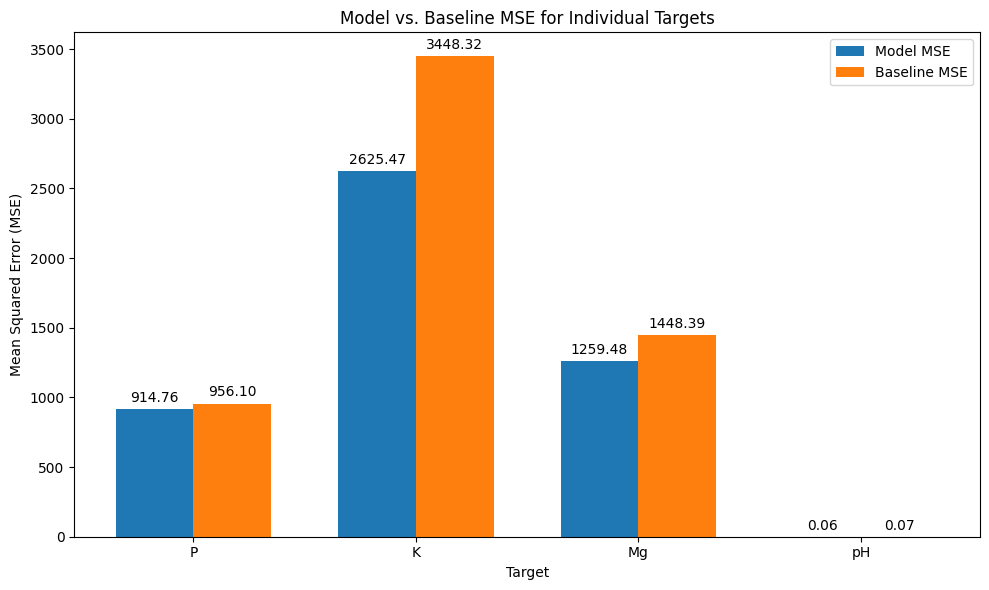

In [45]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

## Generate submission file

In [46]:
import gc

del train_dataset
del val_dataset
del test_dataset
del train_loader
del val_loader
del test_loader

gc.collect()

13781

In [ ]:
# import torch
# torch.cuda.empty_cache()

In [47]:
X_test_submission = load_data("/content/test_data/test")

In [48]:


test_dataset_submission  = NPZDataset(X_test_submission, augment=False, global_means=global_means, global_stds=global_stds)
test_submission_loader  = DataLoader(test_dataset_submission, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [49]:
model.eval() # Set the model to evaluation mode

submission_predictions_scaled = []

with torch.no_grad():
    for X_batch_submission in test_submission_loader:
        # X_batch_submission contains only features, no labels for submission dataset
        X_batch_submission = X_batch_submission.to(next(model.parameters()).device)
        preds_batch = model(X_batch_submission)
        submission_predictions_scaled.append(preds_batch.cpu().numpy())

y_submission_scaled_pred = np.vstack(submission_predictions_scaled)

# Inverse transform predictions to get original values
y_submission_pred = scaler_y.inverse_transform(y_submission_scaled_pred)

# Create submission DataFrame
submission = pd.DataFrame(data=y_submission_pred, columns=["P", "K", "Mg", "pH"])

# Save to CSV
submission.to_csv("submission.csv", index_label="sample_index")
print("Submission file 'submission.csv' created successfully!")

Submission file 'submission.csv' created successfully!
